# Geometry and Physics models validation

In this test, the objectives are:
* Test the generate_naca4() function and get_coords_for_solver() from geometry.py
* Test the AeroSolver() from the physics.py
* Validate the model by comparing the results from the NACA4412 airfoil

For this simulation, the solver used is from **aerosandbox**, being able to do very quick simulation is usefull for the scalling the simulation for the AI application.

In [2]:
%load_ext autoreload
%autoreload 2

import sys
import os

sys.path.append(os.path.abspath(".."))

from src.geometry import AirfoilGeometry
from src.physics import AeroSolver
import matplotlib.pyplot as plt
import numpy as np


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


The foil used for this validation will be the well studied NACA4412. For now the geometry construction type will use the NACA4-digits method.

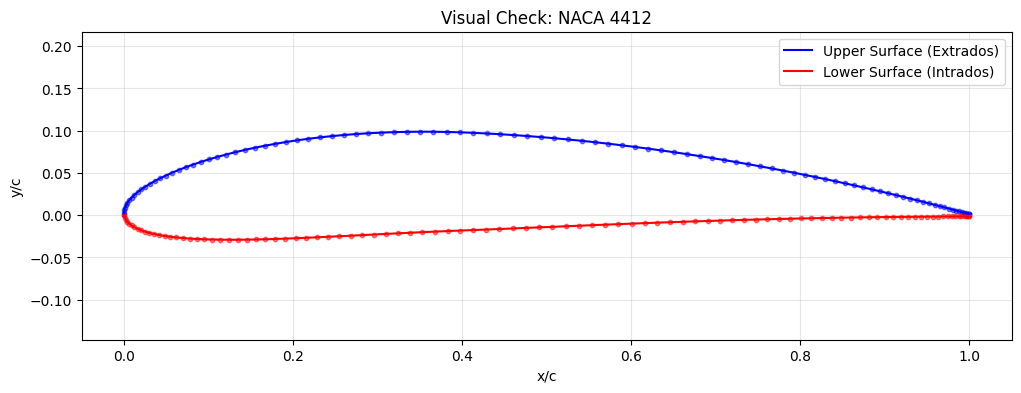

In [3]:
geo = AirfoilGeometry(n_points=100)
xu, yu, xl, yl = geo.generate_naca4(m_int=4, p_int=4, t_int=12) # NACA 4412

geo.plot_naca4(m=4, p=4, t=12)

For the simulation, the geometry has to be converted into coords for the **aerosandbox** solver.

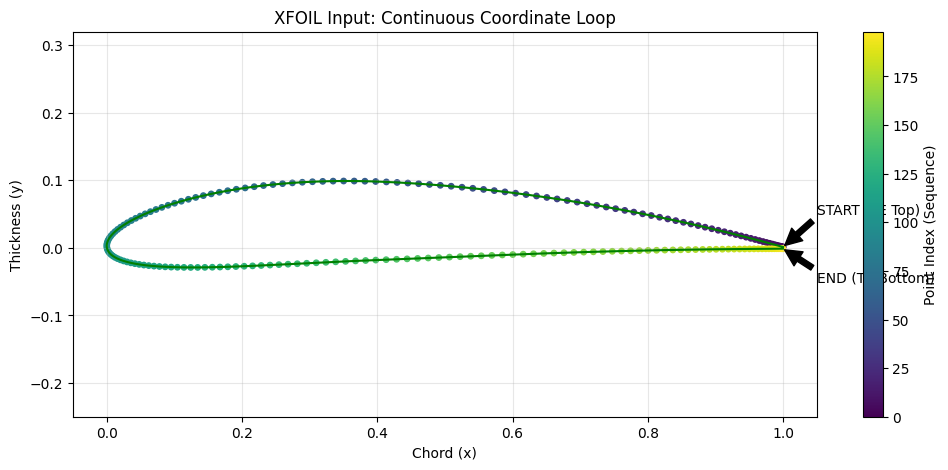

In [4]:
x_solv, y_solv = geo.get_coords_for_solver(xu, yu, xl, yl)

# 3. Visualization
plt.figure(figsize=(12, 5))

# We plot with a single color and dots to see the sequence
plt.plot(x_solv, y_solv, 'g-', linewidth=1.5, label='Solver Path')
plt.scatter(x_solv, y_solv, c=np.arange(len(x_solv)), cmap='viridis', s=15)

# Annotate the start and end to confirm the loop
plt.annotate('START (TE Top)', xy=(x_solv[0], y_solv[0]), xytext=(1.05, 0.05),
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.annotate('END (TE Bottom)', xy=(x_solv[-1], y_solv[-1]), xytext=(1.05, -0.05),
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.title("XFOIL Input: Continuous Coordinate Loop")
plt.xlabel("Chord (x)")
plt.ylabel("Thickness (y)")
plt.axis('equal')
plt.colorbar(label='Point Index (Sequence)')
plt.grid(True, alpha=0.3)
plt.show()

For the validation, the following study is used *2D ANALYSIS OF NACA 4412 AIRFOIL by Mayurkumar kevadiya, Hemish A. Vaidya*

In this paper the following lift and drag curves for NACA4412 profil are the following:

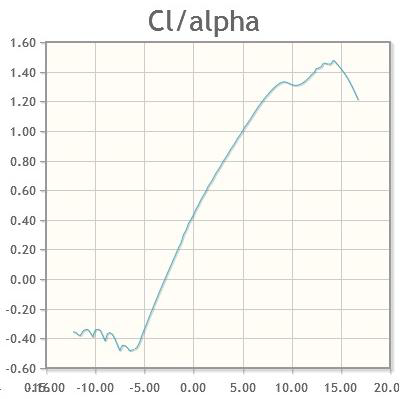 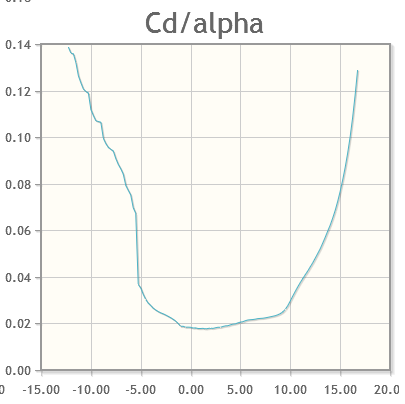

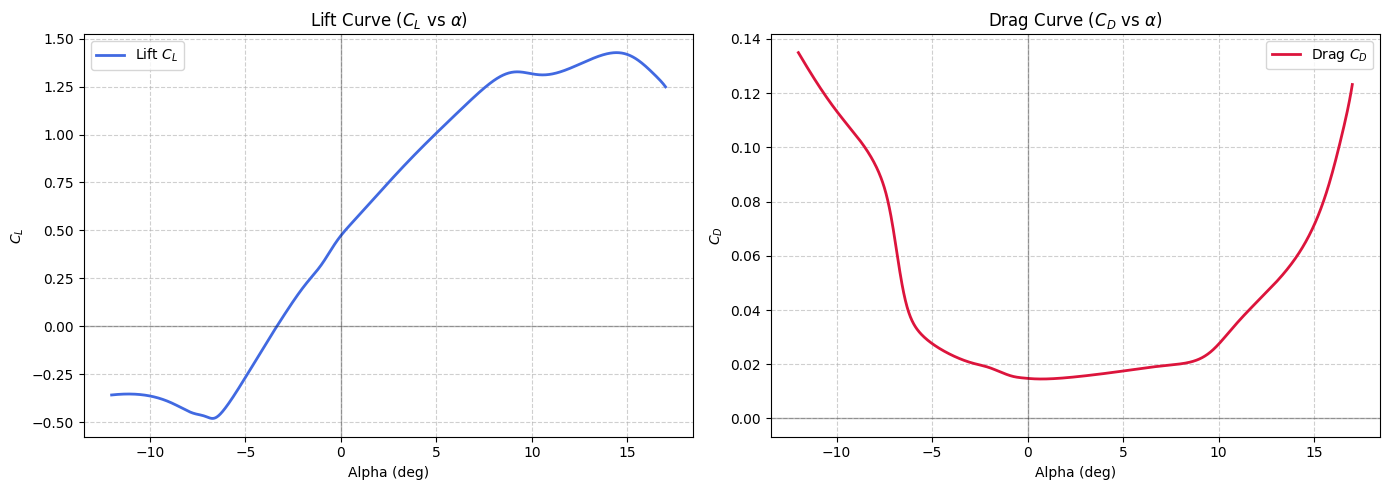

In [5]:
# Test 2: NACA4412 multiple alphas
airfoil4412 = AeroSolver(altitude=0, velocity=18, chord=0.1)

alphas = np.linspace(-12, 17, 1000)

results = airfoil4412.solve(x_solv, y_solv, alpha=alphas)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(alphas, results['cl'], color='royalblue', linewidth=2, label='Lift $C_L$')
ax1.axhline(0, color='black', lw=1, alpha=0.3)
ax1.axvline(0, color='black', lw=1, alpha=0.3)
ax1.set_xlabel("Alpha (deg)")
ax1.set_ylabel("$C_L$")
ax1.set_title("Lift Curve ($C_L$ vs $\\alpha$)")
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend()

ax2.plot(alphas, results['cd'], color='crimson', linewidth=2, label='Drag $C_D$')
ax2.axhline(0, color='black', lw=1, alpha=0.3)
ax2.axvline(0, color='black', lw=1, alpha=0.3)
ax2.set_xlabel("Alpha (deg)")
ax2.set_ylabel("$C_D$")
ax2.set_title("Drag Curve ($C_D$ vs $\\alpha$)")
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend()

plt.tight_layout()

plt.show()

The profils are very similar, so the model can be consider validated.